In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from diptest import diptest

In [2]:
df = pd.read_csv(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\model_data.csv")
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
1,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
2,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
3,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
4,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33.0,Male,France,Nice,4.5,6.0,NaN,6.9,67.1,2.0,...,7.1,8.0,3.0,3.2,12.9,5.0,917.83,1298.0,1,Q4
39996,18.0,Female,France,Lyon,4.8,8.0,21.0,8.4,69.5,3.0,...,17.4,6.0,5.0,15.4,14.6,2.0,813.11,3565.0,1,Q2
39997,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
39998,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3


In [28]:
active_customers = df[df["Churned"] == 0]
active_customers
ui_data = active_customers.sample(10000, random_state = 42)
model_df = df.drop(ui_data.index)

In [34]:
model_df.to_csv(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\model_data.csv",index=False)

In [37]:
ui_data = ui_data.drop(columns="Churned")

In [38]:
ui_data.to_csv(r"C:\Users\91891\Downloads\customer-churn-intelligence-system\data\company_data.csv",index=False)

In [45]:
df.memory_usage(deep=True).sum()

# np.int64(19148486) = bytes

# convert to mb use  # df.memory_usage(deep=True).sum() / 1024 ** 2

np.int64(15319024)

In [3]:
df.shape

(40000, 25)

In [4]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
1,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
2,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
3,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
4,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0,Q1


In [5]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,39990,39991,39992,39993,39994,39995,39996,39997,39998,39999
Age,36.0,45.0,56.0,35.0,56.0,32.0,32.0,40.0,18.0,18.0,...,37.0,63.0,44.0,40.0,29.0,33.0,18.0,38.0,37.0,44.0
Gender,Male,Female,Female,Male,Male,Male,Female,Female,Female,Female,...,Female,Female,Female,Male,Male,Male,Female,Female,Male,Female
Country,UK,Canada,USA,Japan,Germany,UK,Germany,USA,USA,France,...,USA,Canada,France,UK,USA,France,France,USA,USA,USA
City,Manchester,Vancouver,New York,Tokyo,Berlin,Glasgow,Munich,Phoenix,Phoenix,Paris,...,New York,Ottawa,Toulouse,Glasgow,Chicago,Nice,Lyon,Los Angeles,Chicago,Phoenix
Membership_Years,1.6,2.9,2.6,3.5,1.9,0.9,0.6,7.1,3.1,3.7,...,5.4,6.6,4.5,4.0,4.9,4.5,4.8,10.0,1.4,2.8
Login_Frequency,15.0,10.0,10.0,6.0,24.0,0.0,11.0,10.0,13.0,14.0,...,12.0,14.0,5.0,15.0,12.0,6.0,8.0,10.0,21.0,19.0
Session_Duration_Avg,42.7,24.8,38.4,21.9,46.4,12.3,12.1,19.2,26.1,33.5,...,31.1,32.0,22.4,12.7,40.1,NaN,21.0,35.8,32.4,40.3
Pages_Per_Session,10.3,1.6,14.8,6.9,13.9,2.9,5.6,7.0,8.9,10.3,...,5.7,10.2,9.5,8.1,10.2,6.9,8.4,8.8,9.6,10.4
Cart_Abandonment_Rate,37.7,70.9,41.7,74.4,36.2,73.5,77.2,69.1,47.7,48.4,...,80.7,55.8,49.6,68.6,40.7,67.1,69.5,51.2,32.5,50.6
Wishlist_Items,1.0,1.0,9.0,0.0,5.0,0.0,0.0,6.0,2.0,2.0,...,3.0,4.0,9.0,2.0,9.0,2.0,3.0,3.0,2.0,1.0


In [6]:
# so email open rate - how will the company knows whether we opened the email or not,
# they will attach a small image, so whenever we open the mail that image loads form the server
# then server records the email was opened.
# Since the credit balance values are relatively low and consistent with ecommerce transactions, this feature likely represents store credit or wallet balance rather than outstanding debt.
# cohort behavior

# columns
# age - age of the customers
# gender - gender of the customers
# country - country of the customer residence
# City - city of the customer
# Membership_Years - Number of years the customer has been a member of the platform
# Login_Frequency - Average number of logins per month
# Session_Duration_Avg - Average session duration in minutes, in one session 
# Pages_Per_Session - Average of how many pages customer viewed per session
# Cart_Abandonment_Rate - percentage of the abandoned carts in the sessions
# ex 
# session -   Action
# 1       -   Adds x items to cart
# 2       -   Buys x items from cart
# 3       -   Adds x items to cart
# number of times carts created - number of times bought a item(buys) / number of times carts created
# (3 - 1) / 3 = 0.66
# Wishlist_Items - Number of items in customer's wishlist
# Total_Purchases - 
# Average_Order_Value - Average value per order in currency units
# Days_Since_Last_Purchase - Number of days since most recent purchase
# Discount_Usage_Rate - Percentage of purchases using discounts
# Returns_Rate - Percentage of items returned
# Email_Open_Rate - Percentage of marketing emails opened
# the company people will use a small image while sending the mail, whenever a customer opens that mail, it gets notified in the server.
# Customer_Service_Calls - number of times the customer made customer calls.
# Product_Reviews_Written - Number of product reviews submitted
# Social_Media_Engagement_Score - Social media interaction score (0-100)
# Mobile_App_Usage - can also use website, so here it only focuses on activity from mobile app
# Payment_Method_Diversity - Number of different payment methods used
# Lifetime_Value - Total customer lifetime value in currency units - LTV = Sum of all purchases made by customer
# Credit_Balance - store credit or wallet balance
# Churned - target col - 1 - churned and 0 is not churned
# Signup_Quarter - in which quarter they started using our site, sometimes customers uses our website when sale is there, in that way

In [7]:
class MemoryOptimizer():
    def __init__(self,df):
        self.df = df
        self.bool_type = []
        self.int_type = []
        self.float_type = []
        self.object_type = []
        self.category_type = []
        self.datetime = []
        self.threshold = 0.2

    def detect_type(self):
        for col in self.df.columns:
            if pd.api.types.is_bool_dtype(self.df[col]):
                self.bool_type.append(col)
            elif pd.api.types.is_integer_dtype(self.df[col]):
                self.int_type.append(col)
            elif pd.api.types.is_float_dtype(self.df[col]):
                self.float_type.append(col)
            elif pd.api.types.is_object_dtype(self.df[col]):
                self.object_type.append(col)
            elif pd.api.types.is_categorical_dtype(self.df[col]):
                self.category_type.append(col)
            elif pd.api.types.is_datetime64_any_dtype(self.df[col]):
                self.datetime.append(col)
        return self.bool_type,self.int_type,self.float_type,self.object_type,self.category_type,self.datetime

    def optimize_object(self):
        size = len(self.df)
        for col in self.object_type:
            unique_count = len(self.df[col].value_counts())
            ratio = unique_count/size
            if ratio <= self.threshold:
                self.df[col] = self.df[col].astype("category")

    def optimize_numeric(self):
        for col in self.int_type:
            self.df[col] = pd.to_numeric(self.df[col], downcast="integer")
            
        for col in self.float_type:
            # if float values are not actual
            temp_col = self.df[col].dropna()
            
            if (temp_col % 1 == 0).all():
                if self.df[col].isna().any():
                    temp_dtype = pd.to_numeric(temp_col, downcast="integer").dtype
                    nullable_dtype = str(temp_dtype).replace("int","Int")
                    self.df[col] = self.df[col].astype(nullable_dtype)
                # if no nulls
                else:
                    self.df[col] = pd.to_numeric(self.df[col],downcast="integer")
            # if actual float values exist, keep float   
            else:
                self.df[col] = pd.to_numeric(self.df[col], downcast="float")
    

    def optimize(self):
        before = self.df.memory_usage(deep=True).sum() / 1024**2

        self.detect_type()
        self.optimize_object()
        self.optimize_numeric()

        after = self.df.memory_usage(deep=True).sum() / 1024**2
        print("Before memory:", round(before,2),"MB")
        print("After memory:", round(after,2),"MB")
        print("Reduced:", round((before-after) / before * 100,2),"%")
        return self.df

In [8]:
optimizer = MemoryOptimizer(df)
df = optimizer.optimize()

Before memory: 14.61 MB
After memory: 2.71 MB
Reduced: 81.43 %


In [9]:
# here the age col is float value, if really that float matters, we will continue using that, else can convert to discrete
a = (df["Age"] % 1 !=0)
b = a[a==True]
len(b)
# so here the number of non discrete value are 2495 but they are NULL values
# so can convert to discrete
df["Age"].min()
df["Age"].max()

np.int16(200)

In [10]:
df["Age"].isna().sum()

np.int64(1957)

In [11]:
# df["Age"] = df["Age"].astype("int16") -  since there are null values we cant use this
df["Age"] = df["Age"].astype("Int16")  # this is an alternative for null value
# 2nd col gender - object, we can convert to category, as object stores whole string, 
# ex in object = ["female","male"] if male appears 1000 times, it stores 1000 times, which is a waste of memory
# so using category means it stores values like this ["female":0,"male":1] = ["female","male","male","female"] how it is stored is 
# categiry = ["female","male"]
# codes = [0,1,1,0]

In [12]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


In [13]:
df[(df["Login_Frequency"] % 1 != 0)]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,36,Male,UK,Manchester,1.6,15,42.700001,10.3,37.700001,1,...,42.799999,7,3,NaN,23.299999,3,1067.469971,3028,0,Q4
1,45,Female,Canada,Vancouver,2.9,10,24.799999,1.6,70.900002,1,...,0.000000,4,1,NaN,8.800000,<NA>,1289.750000,2317,0,Q4
2,56,Female,USA,New York,2.6,10,38.400002,14.8,41.700001,9,...,41.400002,2,5,85.900002,31.000000,3,2340.919922,2674,0,Q1
3,35,Male,Japan,Tokyo,3.5,6,21.900000,6.9,74.400002,0,...,16.000000,8,2,14.300000,11.200000,2,1995.430054,2418,1,Q1
4,56,Male,Germany,Berlin,1.9,24,46.400002,13.9,36.200001,5,...,35.500000,4,6,68.800003,42.900002,5,3003.570068,2657,0,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,33,Male,France,Nice,4.5,6,NaN,6.9,67.099998,2,...,7.100000,8,3,3.200000,12.900000,5,917.830017,1298,1,Q4
39996,18,Female,France,Lyon,4.8,8,21.000000,8.4,69.500000,3,...,17.400000,6,5,15.400000,14.600000,2,813.109985,3565,1,Q2
39997,38,Female,USA,Los Angeles,10.0,10,35.799999,8.8,51.200001,3,...,9.200000,5,1,20.700001,25.200001,1,2365.979980,3499,0,Q2
39998,37,Male,USA,Chicago,1.4,21,32.400002,9.6,32.500000,2,...,17.600000,5,3,38.599998,12.100000,4,1293.599976,3154,0,Q3


## EDA - Exploratory Data Analysis

### Dividing the data into categories
#### Demographics
* Age
* Gender
* Country
* City
* Membership_Years
* Signup_Quarter

#### Engagement / Behavior
* Login_Frequency
* Session_Duration_Avg
* Pages_Per_Session
* Email_Open_Rate
* Mobile_App_Usage
* Social_Media_Engagement_Score

### Purchase / Transaction
* Total_Purchases
* Average_Order_Value
* Discount_Usage_Rate
* Returns_Rate
* Wishlist_Items
* Cart_Abandonment_Rate
* Days_Since_Last_Purchase
* Payment_Method_Diversity

### Value/Loyalty
* Lifetime_Value
* Credit_Balance
* Product_Reviews_Written
* Customer_Service_Calls

### Target
* Churned

In [16]:
demographics = ["Age","Gender","Country","City","Membership_Years","Signup_Quarter"]
behavior = ["Login_Frequency","Session_Duration_Avg","Pages_Per_Session","Email_Open_Rate","Mobile_App_Usage","Social_Media_Engagement_Score"]
transaction = ["Total_Purchases","Average_Order_Value","Discount_Usage_Rate","Returns_Rate","Wishlist_Items","Cart_Abandonment_Rate","Days_Since_Last_Purchase","Payment_Method_Diversity"]
loyalty = ["Lifetime_Value","Credit_Balance","Product_Reviews_Written","Customer_Service_Calls"]
target = ["Churned"]

### Demographics - EDA - Univariate

In [17]:
class UnivariateAnalysis():
    def __init__(self,df,types):
        self.df = df
        self.types = types
        self.numeric = []
        self.category = []

        
    def divide_cols(self):
        for col in self.types:
            if pd.api.types.is_numeric_dtype(self.df[col]):
                self.numeric.append(col)

            elif pd.api.types.is_categorical_dtype(self.df[col]):
                self.category.append(col)

    def numeric_analysis(self):
        for col in self.numeric:
            fig,axes = plt.subplots(1,2,figsize=(10,4))
            sns.histplot(data = self.df,x=col,ax=axes[0])
            axes[0].set_title(f"Histogram of {col}")
            sns.boxplot(data = self.df,x=col,ax=axes[1])
            axes[1].set_title(f"Boxplot of {col}")
            
            plt.show()

    def category_analysis(self):
        for col in self.category:
            plt.figure(figsize=(8,4))
            sns.countplot(data=self.df,x=col)
            plt.title(f"Countplot of {col}")
            plt.xticks(rotation = 45)
            plt.show()

    def show(self):
        self.divide_cols()
        print(f"In this type {self.types}")
        print(f"Numerical columns are {self.numeric}")
        print(f"Categorical columns are {self.category}")
        return self.numeric_analysis(), self.category_analysis()


In [18]:
# if the col is continuous
# check skewness
# check outliers
# check distribution
# check normality
# check missingness
# check outliers

# if the col is discrete
# frequency distribution
# dominant counts
# zero heavy
# imbalance
# missing
# outliers

# if the col is categorical
# missing
# unique count
# top catgories
# category percentages
# rare categories


In [19]:
l = []
for i in df.columns:
    if df[i].dtype == "float32":
        l.append(i)
l
c = []
for i in df.columns:
    if df[i].dtype == "category":
        c.append(i)
c

['Gender', 'Country', 'City', 'Signup_Quarter']

In [94]:
class UniInsights():
    def __init__(self,df,col):
        self.df = df
        self.col = col
        self.continuous_cols = ["Age",'Membership_Years','Session_Duration_Avg',
                                'Pages_Per_Session','Cart_Abandonment_Rate','Total_Purchases','Average_Order_Value',
                                'Discount_Usage_Rate','Returns_Rate','Email_Open_Rate','Social_Media_Engagement_Score',
                                'Mobile_App_Usage','Lifetime_Value','Days_Since_Last_Purchase','Credit_Balance',"Login_Frequency","Wishlist_Items",
                                "Customer_Service_Calls","Product_Reviews_Written",]
        
        self.discrete_cols = ["Payment_Method_Diversity"]
        self.categorical_cols = ['Churned','Gender', 'Country', 'City', 'Signup_Quarter']

    def missing_values(self):
        missing = self.df[self.col].isna().sum()
        size = len(self.df)
        missing_percentage = (missing/size) * 100
        return missing_percentage

    def outliers(self):
        q1 = self.df[self.col].quantile(0.25)
        q3 = self.df[self.col].quantile(0.75)
        iqr = q3 - q1
        low_whisker = q1 - 1.5 * iqr
        high_whisker = q3 + 1.5 * iqr
        data = self.df[self.col].dropna()
        outliers = ((self.df[self.col] < low_whisker) | (self.df[self.col] > high_whisker)).sum()
        outliers_percentage = (outliers/len(data)) * 100
        return outliers_percentage
        
    
    def categorical_analysis(self):
        print("Unique values:", self.df[self.col].nunique())
        print(self.df[self.col].value_counts(normalize=True)*100)
            
    def discrete_analysis(self):
        print("Unique values:", self.df[self.col].nunique())
        print(self.df[self.col].value_counts().sort_index())


    
    def continuous_analysis(self):
        print("Mean:", self.df[self.col].mean())
        print("Median:", self.df[self.col].median())
        print("Performing dip test..........")
        # as dip test wont work for NA or NAN
        # dip test null hypothesis - the data comes from a unimodal distribution
        # dip test alternate hypothesis - the data comes from multi modal
        temp_col = self.df[self.col].dropna()
        dip,p_value = diptest(temp_col)
        if p_value < 0.05:
            print("Reject H0, that is data is multimodal")
        else:
            print("Data comes from unimodal")
        skewness = self.df[self.col].skew()
        print("Skewness:", skewness)
        if skewness >= -0.5 and skewness <= 0.5:
            print("Approximately Symmetric distribution")
        elif skewness > 0.5:
            print("Positively skewed")
        else:
            print("Negatively skewed")
        print("Min:", self.df[self.col].min())
        print("Max:", self.df[self.col].max())
        
    def flow(self):
        print(f"The column is {self.col}")
        missing_per = self.missing_values()
        print(f"Missing percentage: {missing_per}")
        if self.col in self.categorical_cols:
            self.categorical_analysis()
        elif self.col in self.discrete_cols:
            outliers_per = self.outliers()
            print(f"Outliers percentage {outliers_per}")
            self.discrete_analysis()
        else:
            outliers_per = self.outliers()
            print(f"Outliers percentage {outliers_per}")
            self.continuous_analysis()

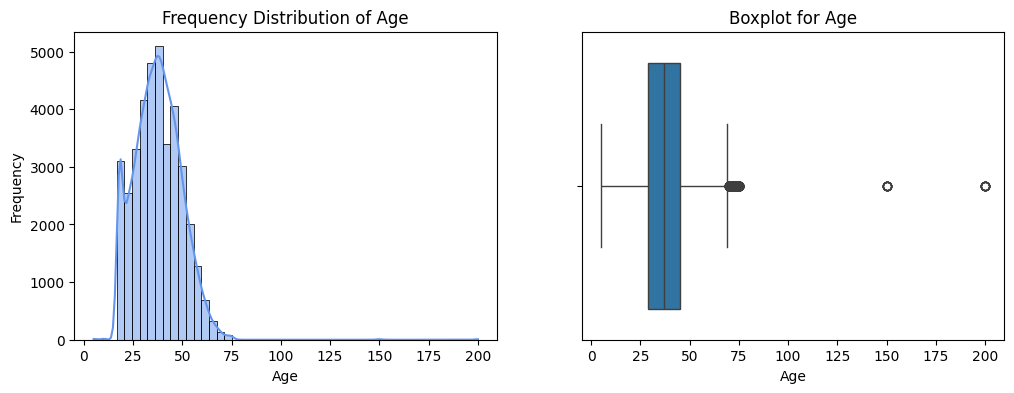

The column is Age
Missing percentage: 4.8925
Outliers percentage 0.38903346213495255
Mean: 37.58604736745262
Median: 37.0
Performing dip test..........
Reject H0, that is data is multimodal
Skewness: 0.9145309937060391
Positively skewed
Min: 5
Max: 200


In [95]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Age",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Age",ax=axes[1])
axes[1].set_title("Boxplot for Age")
axes[1].set_xlabel("Age")

plt.show()

insights_age = UniInsights(df,"Age")
insights_age.flow()

### Insights for Age feature
* Most customers fall betweem the age range of 20-50, with the highest concentration aroung 35-40 and gradual decline after 50, indicates very few elderly/extreme ages customers are there.
* The distribution appears slightly positively skewed due to the presence of higher age values.
* There are outliers, the max age is 200, which is not so possible in real life
* Min age is 5 is also unrealistic for an independent ecommerce customer
* mean and median are close, what does it mean??
* even though mean and median are close, the dip test says not unimodal
* that means the data may still have two peaks/groups
* but overall balance between left/right side is still maintained.

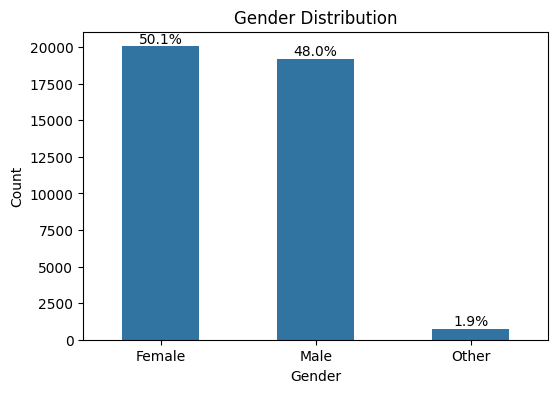

The column is Gender
Missing percentage: 0.0
Unique values: 3
Gender
Female    50.140
Male      47.985
Other      1.875
Name: proportion, dtype: float64


In [96]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df,x="Gender",width=0.5)
for bar in ax.patches: # looping through each bar one by one
    count = bar.get_height() # gets the raw height
    percentage = (count/len(df))*100
    # ax.text(x_position,y_position,text)
    ax.text(bar.get_x() + bar.get_width()/2 ,count+225,f"{percentage:.1f}%",ha="center")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()
insights_gender = UniInsights(df,"Gender")
insights_gender.flow()
# dir(ax)
# dir(bar)

### Insights for Gender feature
* No missing values are present in the Gender feature.
* The feature contains 3 unique categories.
* Whereas male and female genders are nearly equally distributed.
* The other cetagory represents a very small portion of the dataset(1.88%)

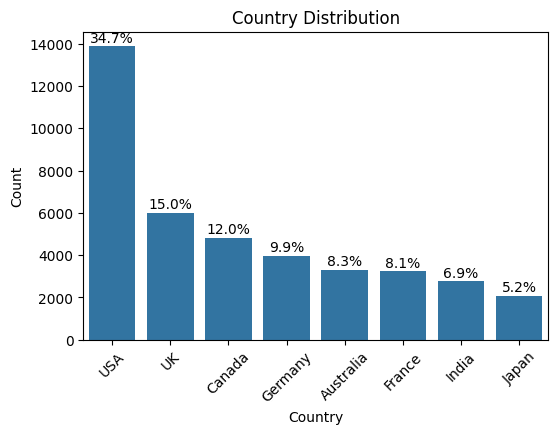

The column is Country
Missing percentage: 0.0
Unique values: 8
Country
USA          34.6825
UK           14.9800
Canada       12.0350
Germany       9.8900
Australia     8.2675
France        8.0750
India         6.9075
Japan         5.1625
Name: proportion, dtype: float64


In [97]:
order = df["Country"].value_counts().index
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df,x="Country",width=0.8,order=order)
for bar in ax.patches: # looping through each bar one by one
    count = bar.get_height() # gets the raw height
    percentage = (count/len(df))*100
    # ax.text(x_position,y_position,text)
    ax.text(bar.get_x() + bar.get_width()/2 ,count+200,f"{percentage:.1f}%",ha="center")
plt.title("Country Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
insights_gender = UniInsights(df,"Country")
insights_gender.flow()
# dir(ax)
# dir(bar)

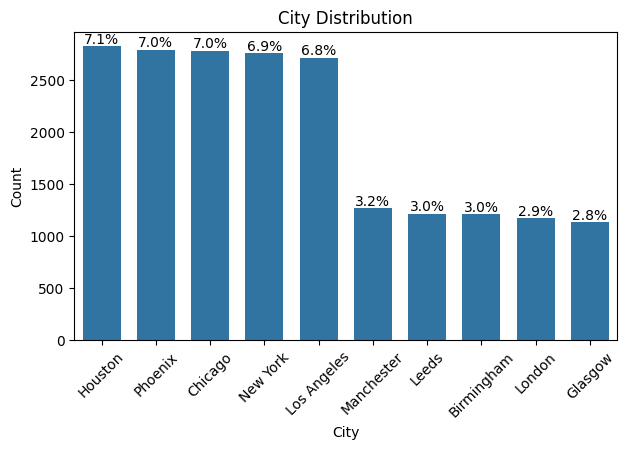

The column is City
Missing percentage: 0.0
Unique values: 40
City
Houston        7.0625
Phoenix        6.9825
Chicago        6.9525
New York       6.8975
Los Angeles    6.7875
Manchester     3.1650
Leeds          3.0325
Birmingham     3.0225
London         2.9275
Glasgow        2.8325
Montreal       2.4700
Ottawa         2.4000
Toronto        2.3925
Calgary        2.3875
Vancouver      2.3850
Hamburg        2.0775
Cologne        2.0625
Berlin         2.0275
Munich         1.9275
Frankfurt      1.7950
Sydney         1.6825
Perth          1.6775
Toulouse       1.6525
Brisbane       1.6500
Adelaide       1.6425
Nice           1.6325
Lyon           1.6275
Melbourne      1.6150
Marseille      1.5900
Paris          1.5725
Chennai        1.5025
Mumbai         1.3775
Bangalore      1.3550
Delhi          1.3450
Hyderabad      1.3275
Tokyo          1.1025
Kyoto          1.0675
Nagoya         1.0075
Osaka          1.0000
Yokohama       0.9850
Name: proportion, dtype: float64


In [98]:
order = df["City"].value_counts().head(10).index
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df,x="City",width=0.7,order = order)
for bar in ax.patches: # looping through each bar one by one
    count = bar.get_height() # gets the raw height
    percentage = (count/len(df))*100
    # ax.text(x_position,y_position,text)
    # ax.text(count+220,bar.get_y() + bar.get_height()/2 ,f"{percentage:.1f}%",va="center")
    ax.text(bar.get_x() + bar.get_width()/2 ,count+30,f"{percentage:.1f}%",ha="center")
plt.title("City Distribution")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
insights_gender = UniInsights(df,"City")
insights_gender.flow()
# dir(ax)
# dir(bar)

In [99]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [100]:
discrete_cols = [
    "Login_Frequency",
    "Wishlist_Items",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
    "Payment_Method_Diversity"]
# the first 4 features contain relatively higher unique discrete values,
# so histogram with discrete=True are used to better visualize their distributions.
# Payment method has very low cardinality (only a few unique values)
# so a countplot is more suitable for visualizing category frequencies
# i can also use count plots for all the features, but as there are more unique counts
# However, for features
# with higher cardinality, histograms provide cleaner distribution visualization
# and help in understanding skewness and overall distribution shape.
# so i changed the lists in UniInsights class

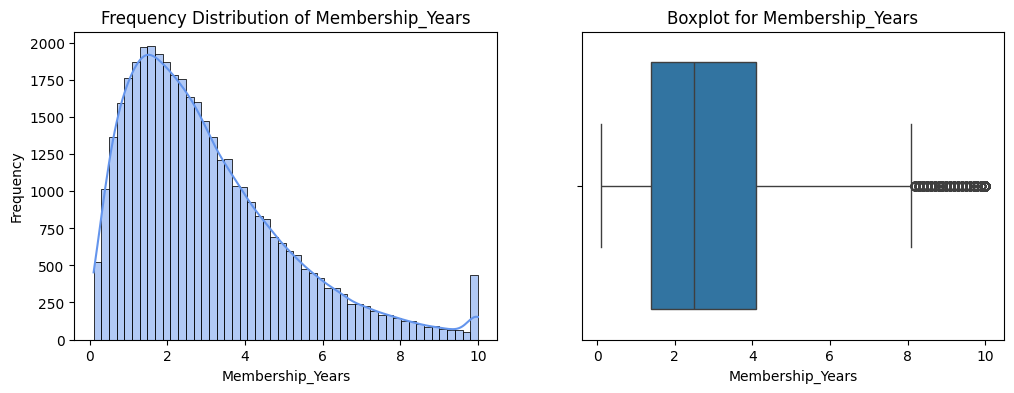

The column is Membership_Years
Missing percentage: 0.0
Outliers percentage 2.8375
Mean: 2.9884396
Median: 2.5
Performing dip test..........
Reject H0, that is data is multimodal
Skewness: 1.132526
Positively skewed
Min: 0.1
Max: 10.0


In [104]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Membership_Years",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Membership_Years")
axes[0].set_xlabel("Membership_Years")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Membership_Years",ax=axes[1])
axes[1].set_title("Boxplot for Membership_Years")
axes[1].set_xlabel("Membership_Years")

plt.show()

insights_age = UniInsights(df,"Membership_Years")
insights_age.flow()

### Insights
* From the histogram
* Most customers have lower membership years.
* Freq gradually decreases as membership years increases.
* Distribution is clearly possitively skewed
* Many values small
* Long right tail
* Also we saw mean = 2.9 > median 2.5 which also indicates positively skewed.
* The boxplot show
* several high-end outliers aroung 8-10 years
* they are like long term loyal customers
* So business wise - these may actually be valuable customers, not bad data
* so dont remove them blindly - for me
* Imp issuse is diptest says data is multimodal, but visually it is unimodal+skewed
* This can happen because
* large datasets are very sensitive
* dip test detects even tiny deviations
* skewed distributions sometimes trigger significance

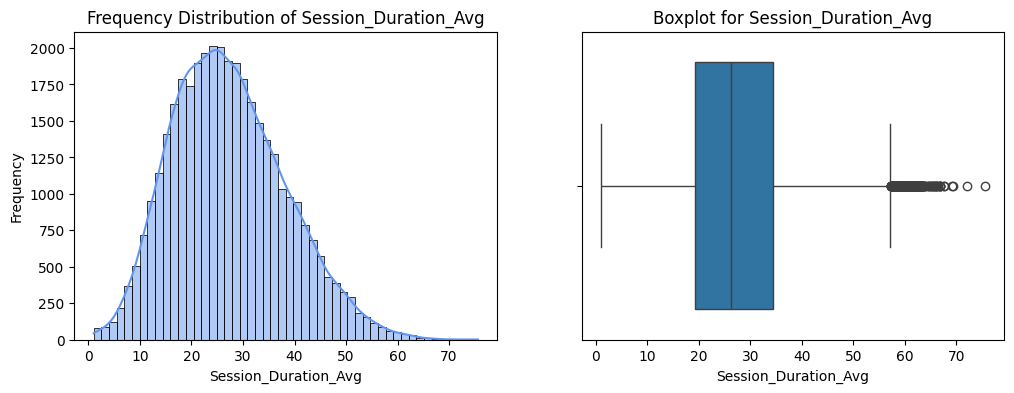

The column is Session_Duration_Avg
Missing percentage: 7.145
Outliers percentage 0.6057832103817781
Mean: 27.267181
Median: 26.3
Performing dip test..........
Data comes from unimodal
Skewness: 0.4079338
Approximately Symmetric distribution
Min: 1.0
Max: 75.6


In [105]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Session_Duration_Avg",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Session_Duration_Avg")
axes[0].set_xlabel("Session_Duration_Avg")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Session_Duration_Avg",ax=axes[1])
axes[1].set_title("Boxplot for Session_Duration_Avg")
axes[1].set_xlabel("Session_Duration_Avg")

plt.show()

insights_age = UniInsights(df,"Session_Duration_Avg")
insights_age.flow()

### Insights
* The Session_Duration_Avg feature contains approximately 7.15% missing values.
* The distribution appears unimodal with a single dominant peak.
* The feature shows an approximately symmetric distribution with slight positive skewness (Skewness ≈ 0.41).
* Mean (27.27) and median (26.3) are relatively close, further indicating near-symmetric behavior.
* Most customers have moderate session durations, while extremely high session durations are comparatively less frequent.
* Approximately 0.61% of observations are identified as outliers, primarily on the higher end of the distribution.
* Customers with longer session durations may indicate higher engagement levels and stronger interaction with the platform.
* Since the feature is relatively well-distributed with limited outliers, extensive transformation may not be necessary before modeling.

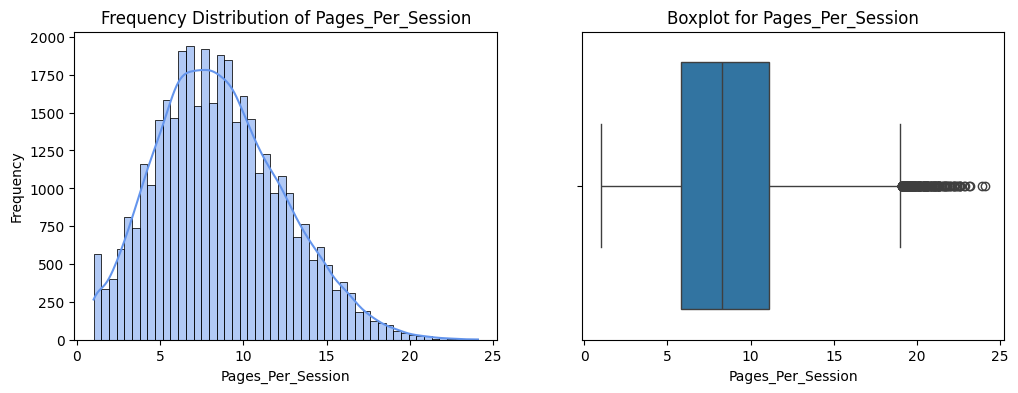

The column is Pages_Per_Session
Missing percentage: 5.9775
Outliers percentage 0.5610359222526523
Mean: 8.60983
Median: 8.3
Performing dip test..........
Reject H0, that is data is multimodal
Skewness: 0.39782694
Approximately Symmetric distribution
Min: 1.0
Max: 24.1


In [106]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Pages_Per_Session",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Pages_Per_Session")
axes[0].set_xlabel("Pages_Per_Session")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Pages_Per_Session",ax=axes[1])
axes[1].set_title("Boxplot for Pages_Per_Session")
axes[1].set_xlabel("Pages_Per_Session")

plt.show()

insights_age = UniInsights(df,"Pages_Per_Session")
insights_age.flow()

### Insights for Pages_Per_Session Feature
* The feature contains approximately 5.98% missing values.
* The distribution appears approximately unimodal with a single dominant peak.
* The feature shows slight positive skewness (Skewness ≈ 0.40) but remains approximately symmetric overall.
* Mean (8.61) and median (8.3) are relatively close, supporting near-symmetric behavior.
* Most customers visit a moderate number of pages per session, while very high page counts are less common.
* Approximately 0.56% of observations are identified as high-end outliers.
* Customers with higher pages per session may indicate stronger browsing behavior and platform engagement.
* The feature appears reasonably well-distributed and may not require heavy transformation before modeling.

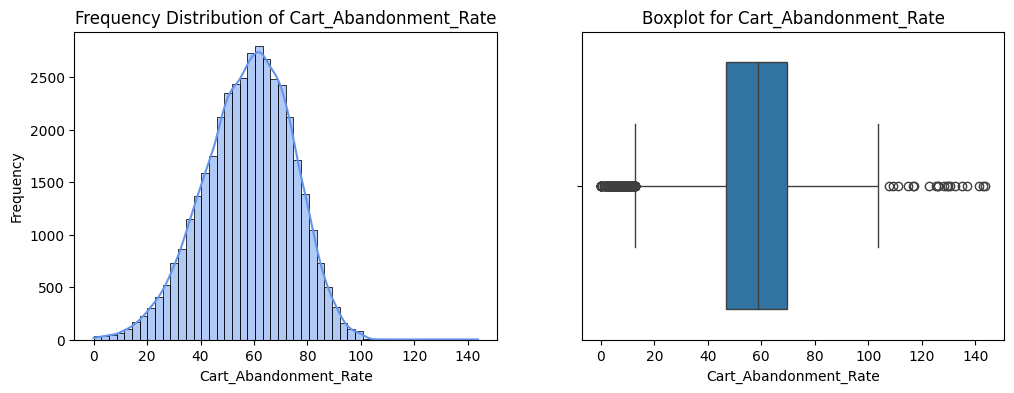

The column is Cart_Abandonment_Rate
Missing percentage: 0.0
Outliers percentage 0.6125
Mean: 57.782463
Median: 58.8
Performing dip test..........
Data comes from unimodal
Skewness: -0.26235375
Approximately Symmetric distribution
Min: 0.0
Max: 143.74335


In [107]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Cart_Abandonment_Rate",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Cart_Abandonment_Rate")
axes[0].set_xlabel("Cart_Abandonment_Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Cart_Abandonment_Rate",ax=axes[1])
axes[1].set_title("Boxplot for Cart_Abandonment_Rate")
axes[1].set_xlabel("Cart_Abandonment_Rate")

plt.show()

insights_age = UniInsights(df,"Cart_Abandonment_Rate")
insights_age.flow()

### Insights
#### main thing is this is percentage of cart_abandonment_rate, but here max value is 143 which is exceeding 100 which may indicate data quality issues, scaling inconsistencies, or synthetic data generation artifacts.
* No missing values are present in the feature.
* The distribution appears approximately unimodal and symmetric.
* Mean (57.78) and median (58.8) are relatively close, supporting near-symmetric behavior.
* Skewness (-0.26) indicates only slight negative skewness.
* Approximately 0.61% of observations are identified as outliers on both lower and higher ends.
* Most customers exhibit moderate cart abandonment behavior centered around the middle range.
* Extremely high abandonment rates may indicate checkout friction, low purchase intent, or browsing-focused behavior.
* Values exceeding 100 are observed, which may indicate potential data inconsistencies or synthetic data artifacts and should be validated before modeling.

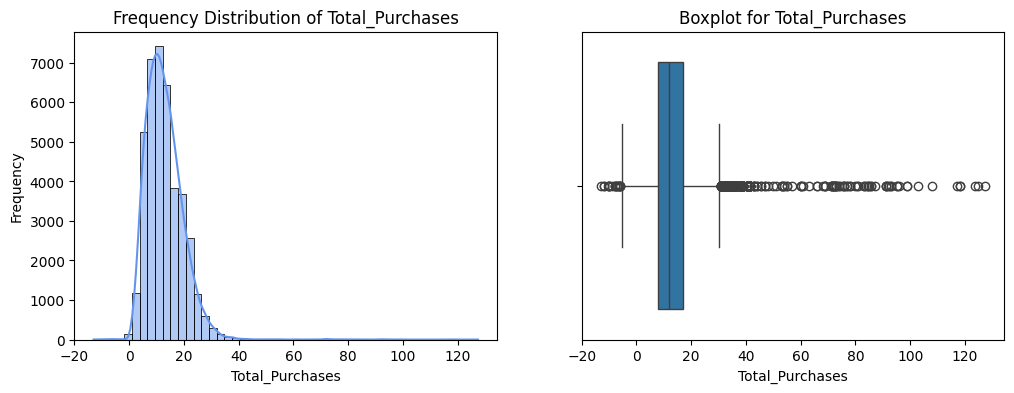

The column is Total_Purchases
Missing percentage: 0.0
Outliers percentage 1.2349999999999999
Mean: 12.926246
Median: 12.0
Performing dip test..........
Reject H0, that is data is multimodal
Skewness: 2.4730644
Positively skewed
Min: -13.0
Max: 127.4


In [108]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Total_Purchases",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Total_Purchases")
axes[0].set_xlabel("Total_Purchases")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Total_Purchases",ax=axes[1])
axes[1].set_title("Boxplot for Total_Purchases")
axes[1].set_xlabel("Total_Purchases")

plt.show()

insights_age = UniInsights(df,"Total_Purchases")
insights_age.flow()

### Insights
Outliers exist mainly on:

✅ higher purchase side

These may represent:

loyal customers
premium customers
bulk buyers
highly engaged users

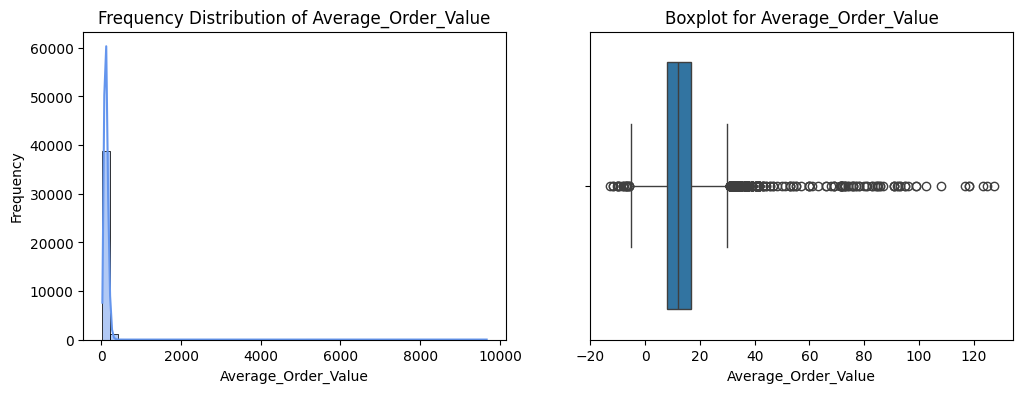

The column is Average_Order_Value
Missing percentage: 0.0
Outliers percentage 1.9924999999999997
Mean: 125.136536
Median: 113.96
Performing dip test..........
Data comes from unimodal
Skewness: 39.224022
Positively skewed
Min: 26.87
Max: 9666.379


In [102]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Average_Order_Value",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Average_Order_Value")
axes[0].set_xlabel("Average_Order_Value")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Total_Purchases",ax=axes[1])
axes[1].set_title("Boxplot for Average_Order_Value")
axes[1].set_xlabel("Average_Order_Value")

plt.show()

insights_age = UniInsights(df,"Average_Order_Value")
insights_age.flow()

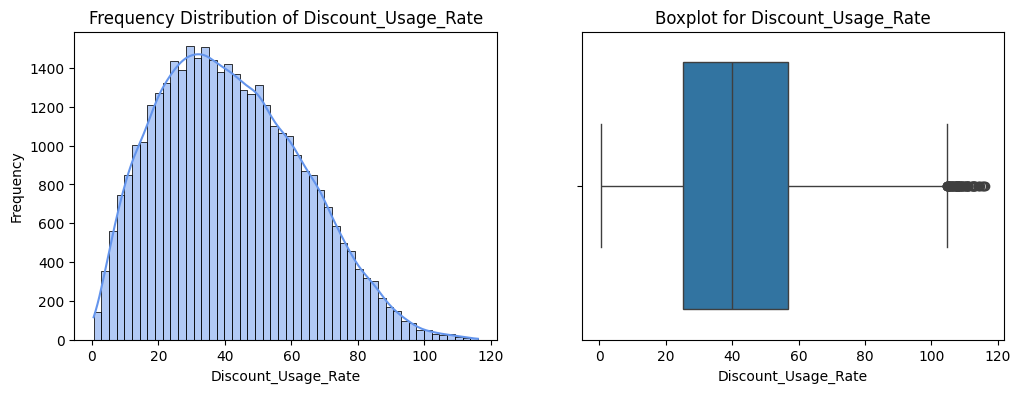

The column is Discount_Usage_Rate
Missing percentage: 6.915
Outliers percentage 0.22291454047376055
Mean: 41.74135
Median: 39.9
Performing dip test..........
Data comes from unimodal
Skewness: 0.3812094
Approximately Symmetric distribution
Min: 0.5
Max: 116.16


In [103]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Discount_Usage_Rate",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Discount_Usage_Rate")
axes[0].set_xlabel("Discount_Usage_Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Discount_Usage_Rate",ax=axes[1])
axes[1].set_title("Boxplot for Discount_Usage_Rate")
axes[1].set_xlabel("Discount_Usage_Rate")

plt.show()

insights_age = UniInsights(df,"Discount_Usage_Rate")
insights_age.flow()

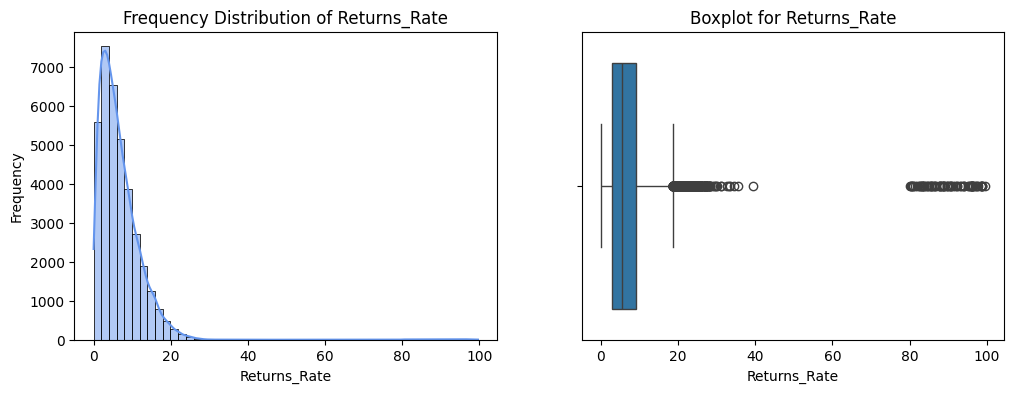

The column is Returns_Rate
Missing percentage: 8.955
Outliers percentage 2.498764347300785
Mean: 6.720104
Median: 5.5
Performing dip test..........
Reject H0, that is data is multimodal
Data comes from unimodal
Skewness: 5.7907104
Positively skewed
Min: 0.0
Max: 99.61573


In [92]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Returns_Rate",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Returns_Rate")
axes[0].set_xlabel("Returns_Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Returns_Rate",ax=axes[1])
axes[1].set_title("Boxplot for Returns_Rate")
axes[1].set_xlabel("Returns_Rate")

plt.show()

insights_age = UniInsights(df,"Returns_Rate")
insights_age.flow()

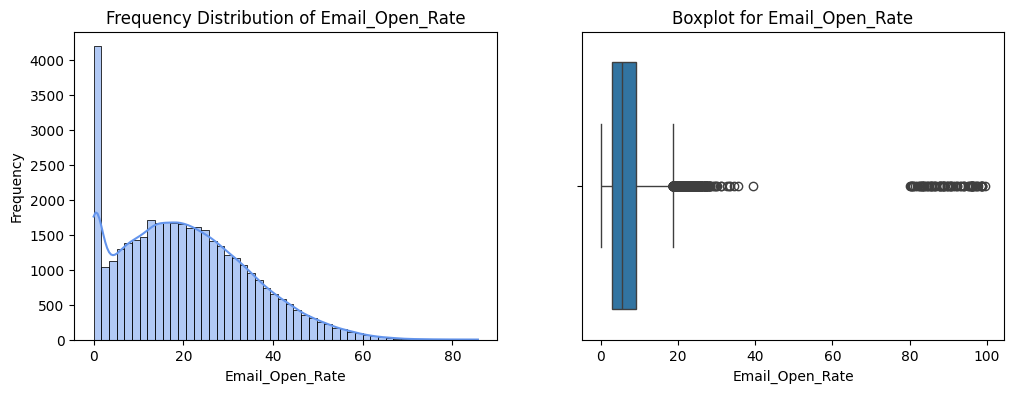

The column is Email_Open_Rate
Missing percentage: 5.1499999999999995
Outliers percentage 0.4665260938323669
Mean: 20.427364
Median: 19.2
Performing dip test..........
Reject H0, that is data is multimodal
Data comes from unimodal
Skewness: 0.5151788
Positively skewed
Min: 0.0
Max: 85.7


In [93]:
figure,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(data=df,x="Email_Open_Rate",color="cornflowerblue",kde=True,bins=50,ax=axes[0])
axes[0].set_title("Frequency Distribution of Email_Open_Rate")
axes[0].set_xlabel("Email_Open_Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df,x="Returns_Rate",ax=axes[1])
axes[1].set_title("Boxplot for Email_Open_Rate")
axes[1].set_xlabel("Email_Open_Rate")

plt.show()

insights_age = UniInsights(df,"Email_Open_Rate")
insights_age.flow()

In [ ]:
       self.continuous_cols = ["Age",'Membership_Years','Session_Duration_Avg',
                                'Pages_Per_Session','Cart_Abandonment_Rate','Total_Purchases','Average_Order_Value',
                                'Discount_Usage_Rate','Returns_Rate','Email_Open_Rate','Social_Media_Engagement_Score',
                                'Mobile_App_Usage','Lifetime_Value','Days_Since_Last_Purchase','Credit_Balance',"Login_Frequency","Wishlist_Items",
                                "Customer_Service_Calls","Product_Reviews_Written",]

In [157]:
c = []
for i in df.columns:
    if df[i].dtype == "category":
        l.append(i)
l

['Gender', 'Country', 'City', 'Signup_Quarter']

In [145]:
df["Age"].dtype

Int16Dtype()

In [70]:
numeric_cols = df.select_dtypes(include="number")
numeric_cols.shape

(40000, 21)

In [ ]:
discrete_cols = ["Login_Frequency","Wishlist_Items","Customer_Service_Calls","Product_Reviews_Written","Payment_Method_Diversity",]

In [59]:
def missing_percentage(dataset):
    m_p = {"column" :[], "missing_percentage" : []}
    for i in dataset.columns:
        missing = dataset[i].isna().sum()
        total = len(dataset)
        missing_percentage = round((missing / total) * 100,2)
        m_p["column"].append(i)
        m_p["missing_percentage"].append(missing_percentage)
    m = pd.DataFrame(m_p)
    return m

In [60]:
missing_percentage(df)

,column,missing_percentage
0,Age,4.89
1,Gender,0.00
2,Country,0.00
3,City,0.00
4,Membership_Years,0.00
5,Login_Frequency,0.00
6,Session_Duration_Avg,7.14
7,Pages_Per_Session,5.98
8,Cart_Abandonment_Rate,0.00
9,Wishlist_Items,8.02


In [62]:
s = []
for i in df.columns:
    if df[i].isna().any():
      s.append(i)
s

['Age',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Wishlist_Items',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Credit_Balance']

<Axes: >

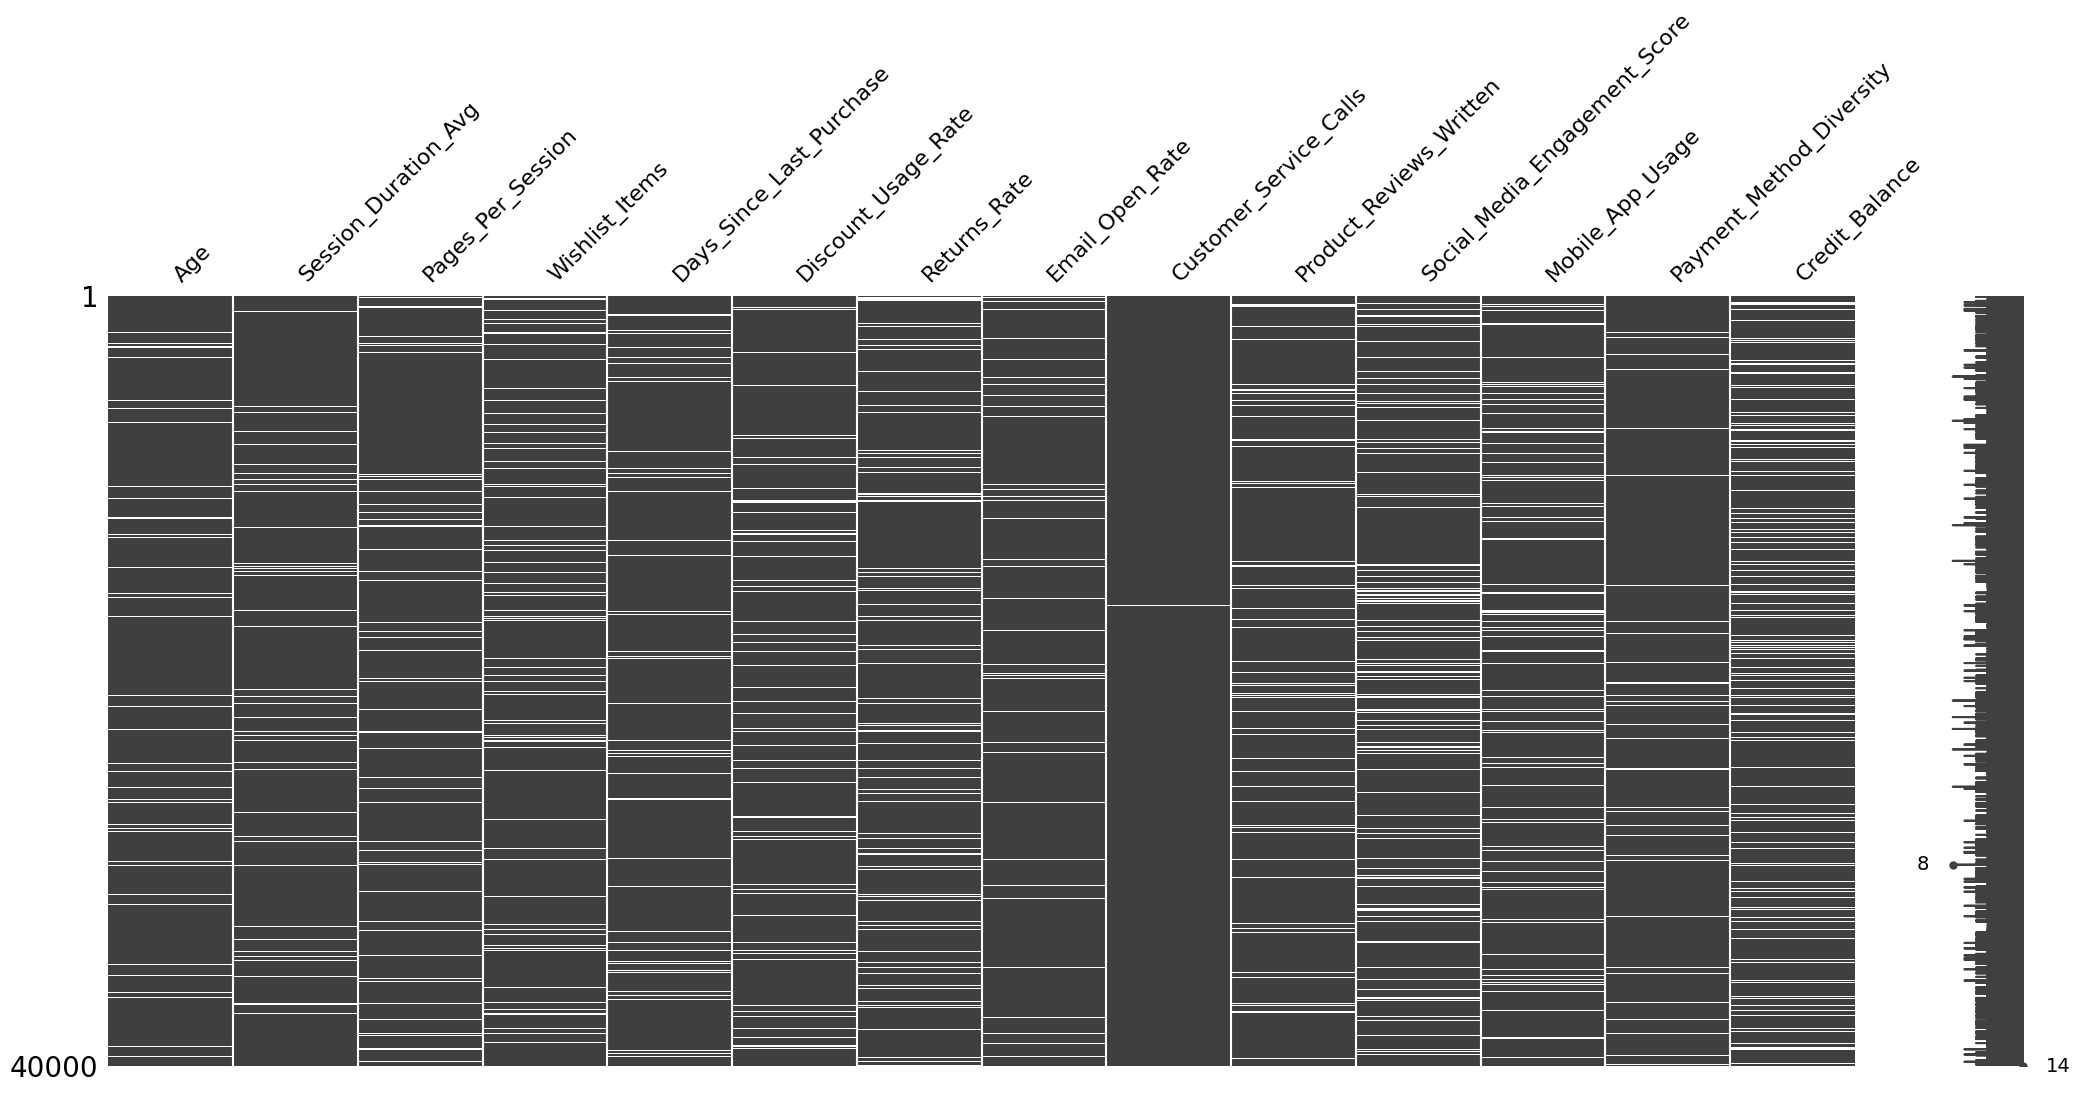

In [63]:
import missingno as msno
msno.matrix(df[s])

In [116]:
# lets count missing values per row
df.isna().sum(axis = 1).value_counts()
# so here maximum value in value count is 6 which is 24% that is 6/no of cols, so
# if i remove rows i can lose data unnecessarily.
# Row sparsity was low, so I retained rows and used imputation.

1    19150
0    17983
2     9437
3     2764
4      577
5       77
6       12
Name: count, dtype: int64

In [117]:
df[["Age","Membership_Years"]]

,Age,Membership_Years
0,43,2.9
1,36,1.6
2,45,2.9
3,56,2.6
4,35,3.1
...,...,...
49995,38,10.0
49996,37,1.4
49997,44,2.8
49998,41,2.9


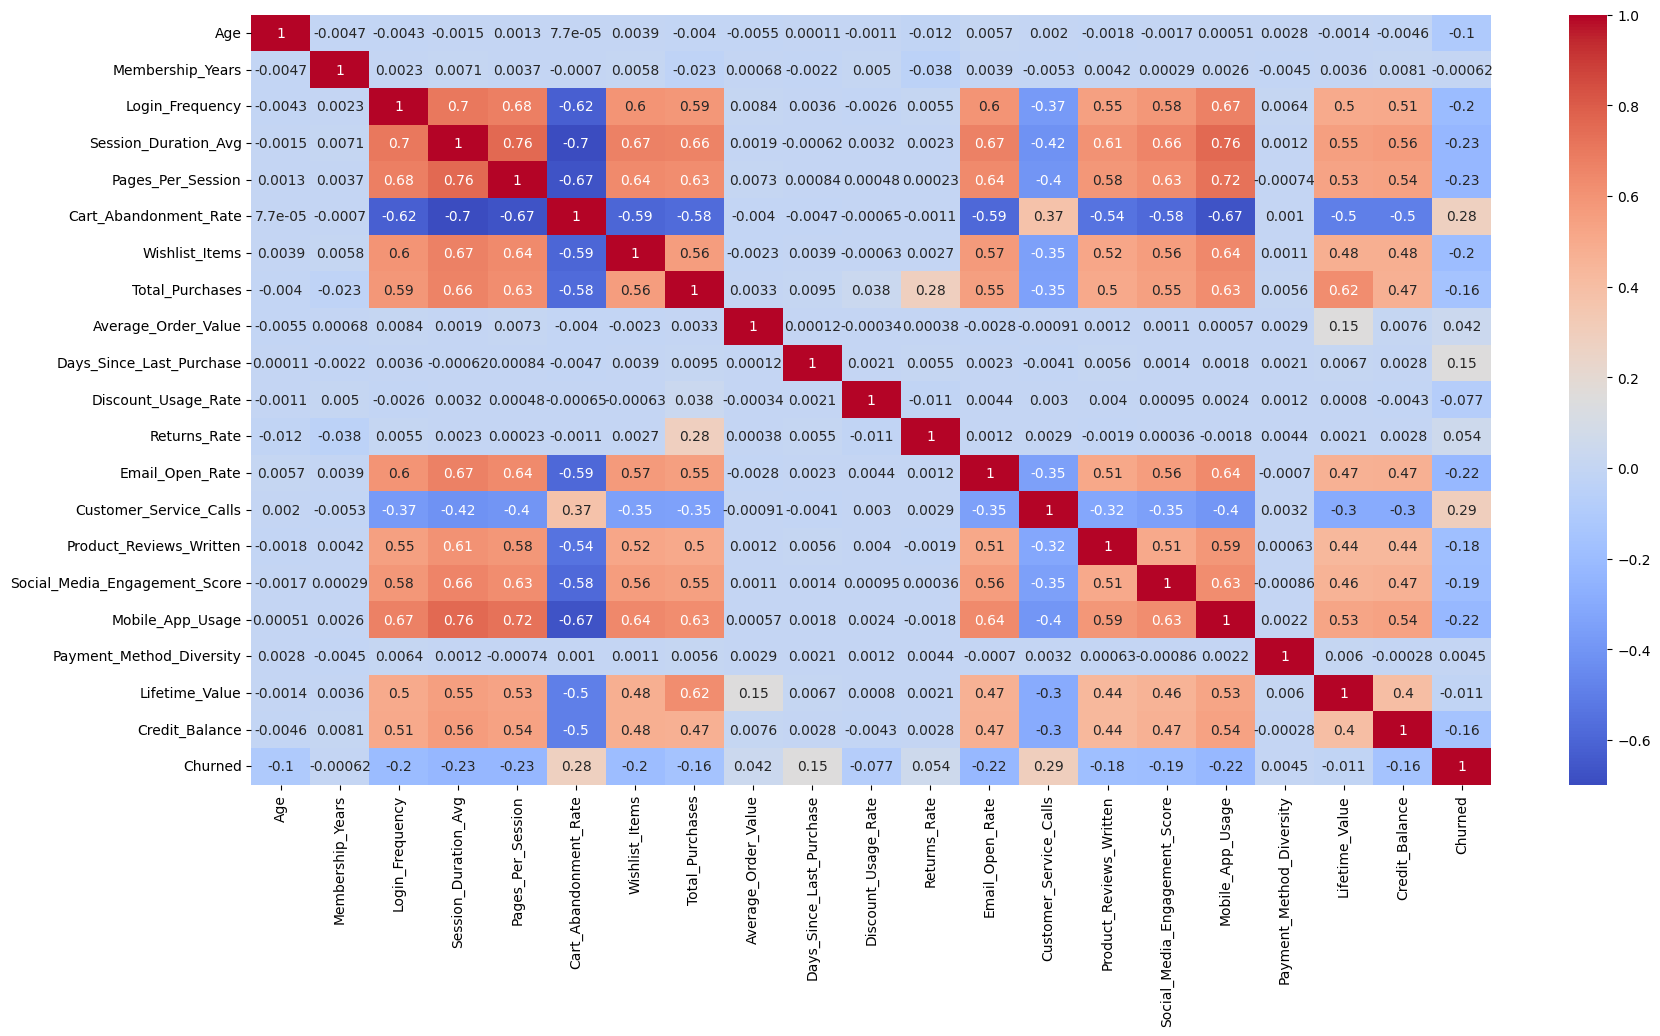

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            47505 non-null  Int16   
 1   Gender                         50000 non-null  category
 2   Country                        50000 non-null  category
 3   City                           50000 non-null  category
 4   Membership_Years               50000 non-null  float32 
 5   Login_Frequency                50000 non-null  int8    
 6   Session_Duration_Avg           46601 non-null  float32 
 7   Pages_Per_Session              47000 non-null  float32 
 8   Cart_Abandonment_Rate          50000 non-null  float32 
 9   Wishlist_Items                 46000 non-null  Int8    
 10  Total_Purchases                50000 non-null  float32 
 11  Average_Order_Value            50000 non-null  float32 
 12  Days_Since_Last_Purchase       4

<Axes: xlabel='Age', ylabel='Count'>

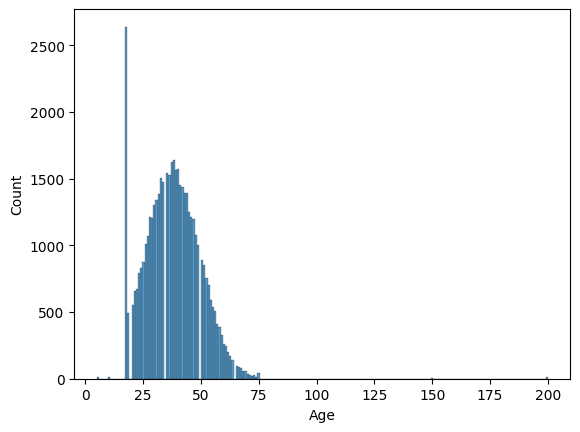

In [12]:
sns.histplot(data=df,x="Age")

In [ ]:
# here we can see most of the customers are from 25 to 75 age group, we can also see a customer with 200 age, maybe thats an outlier.

<Axes: xlabel='Gender', ylabel='count'>

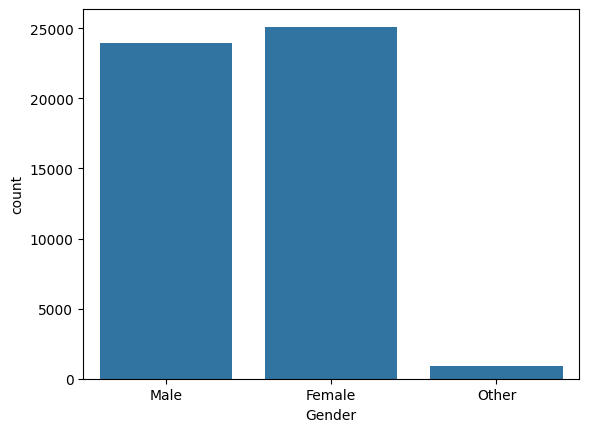

In [13]:
sns.countplot(data=df,x="Gender")

In [ ]:
# coming to the gender distribution, there is an equal share between female and male, with more female and little part as others.

In [22]:
df["Country"].value_counts()
# total 8 countries

Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

In [15]:
df["City"].value_counts()

City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Perth           817
Adelaide        817
Toulouse        815
Melbourne       805
Nice            799
Brisbane        794
Marseille       793
Paris           776
Chennai         736
Bangalore       698
Mumbai          694
Delhi           693
Hyderabad       691
Tokyo           537
Nagoya          514
Kyoto           507
Osaka           496
Yokohama        494
Name: count, dtype: int64

<Axes: ylabel='City'>

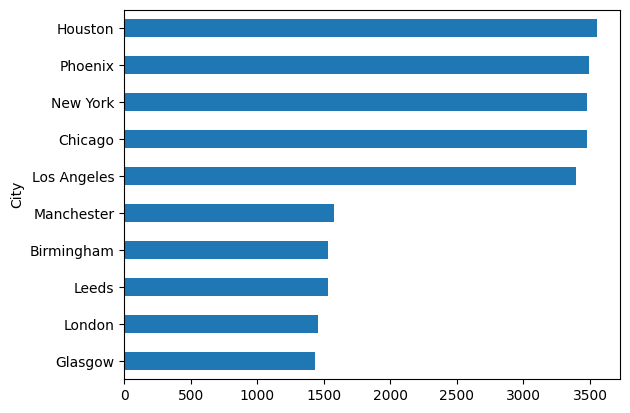

In [23]:
df["City"].value_counts().head(10).sort_values().plot(kind="barh")
# these are the top 

<Axes: xlabel='Membership_Years', ylabel='Count'>

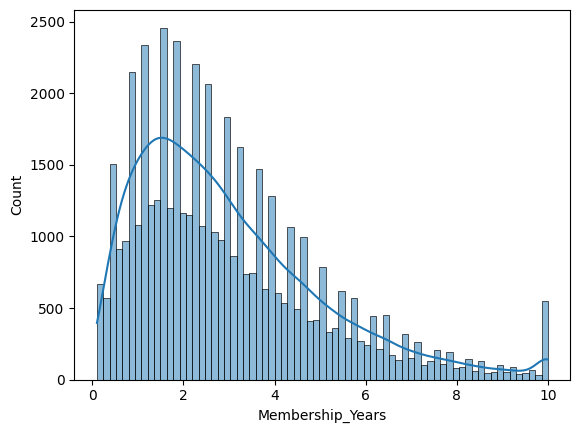

In [20]:
sns.histplot(data=df,x="Membership_Years",kde="True")

In [19]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [24]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [7]:
df["Country"].value_counts()

Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

In [12]:
df.groupby("Country")["Lifetime_Value"].mean()

Country
Australia    1443.163772
Canada       1427.204156
France       1451.532988
Germany      1447.675927
India        1458.122170
Japan        1457.026417
UK           1436.718782
USA          1435.923976
Name: Lifetime_Value, dtype: float64

In [8]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [18]:
df["Churned"].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64